# UrbanPulse — Notebook 07: ECHO Stage A — Personality Atlas

Bible §7 Stage A. Assigns each link a behavioral archetype from its 8-dim temporal fingerprint.

**B7 decisions/findings:**
- #8 → MVB k-means. #9 → two-pass adjacency (lag-correlation seed, used by Stage B).
- **Spatial penalty dropped:** it pulls *adjacent* links together, but Link 36↔37 are adjacent, so it merged the roads the Bible wanted separated and lowered silhouette. Spatial structure is used in Stage B instead.
- **No Landmine in the data:** Link 36 has a high off-peak floor (356s, congested at 3 AM) and co-clusters with Chronic Link 37 — it is empirically Chronic/Saturator-like, not a Landmine.

**Produces:** `data/road_archetypes.json`, `reports/echo/personality_atlas.png`.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import config, io_utils
from echo import personality_atlas as atlas
import pandas as pd

## 1. Fingerprints (66 links x 8 features)

In [2]:
feats = io_utils.load_parquet(config.FEATURES_PARQUET)
fp = atlas.extract_fingerprints(feats)
fp.round(2).head()

,peak_severity,off_peak_floor,spike_frequency,recovery_speed,lane6_utilization,stall_rate,speed_divergence_mean,occupancy_variance
LINK_ID,,,,,,,,
1,263.72,166.72,0.00,-18.43,1.0,0.0,2.23,0.12
2,290.61,170.27,0.00,-22.28,0.0,0.0,1.93,0.10
3,240.78,154.73,0.00,-20.58,1.0,0.0,2.43,0.10
4,305.71,182.27,0.00,-19.42,0.0,0.0,1.73,0.13
5,486.74,299.38,0.04,-31.55,0.0,0.0,4.08,0.06


## 2. Run the full Atlas

In [3]:
out = atlas.run()
print('silhouette:', round(out['silhouette'],3))
print('archetypes:', out['archetype_counts'])
print('stable:', out['n_stable'], '/ 66')

Step 1: fingerprints ...
Step 2: lag-correlation adjacency ...


  adjacency edges: 366
Step 3: fingerprint k-means (spatial penalty disabled, B7 decision) ...
  silhouette: 0.265
Step 4: archetype assignment ...
Step 5: stability ...


silhouette: 0.265
archetypes: {'Chameleon': 22, 'Commuter': 18, 'Saturator': 16, 'Ghost': 8, 'Chronic': 2}
stable: 57 / 66


## 3. Archetype roster

In [4]:
d = json.loads(config.ROAD_ARCHETYPES_JSON.read_text())
roster = pd.DataFrame([{'link':int(k), **v} for k,v in d.items()])
roster.groupby('archetype').agg(n=('link','size'),
    mean_conf=('confidence','mean'), mean_stab=('stability_score','mean')).round(3)

,n,mean_conf,mean_stab
archetype,,,
Chameleon,22,0.639,0.964
Chronic,2,0.642,1.000
Commuter,18,0.674,1.000
Ghost,8,0.623,0.955
Saturator,16,0.580,0.692


## 4. Key links (note Link 36 = Chronic, not the Bible's 'Landmine')

In [5]:
roster[roster.link.isin([36,37,5,17,1])].set_index('link')

,archetype,confidence,stability_score,stable
link,,,,
1,Ghost,0.7108,1.0,True
5,Saturator,0.5754,1.0,True
17,Saturator,0.5628,1.0,True
36,Chronic,0.5638,1.0,True
37,Chronic,0.7207,1.0,True


## 5. Atlas projection

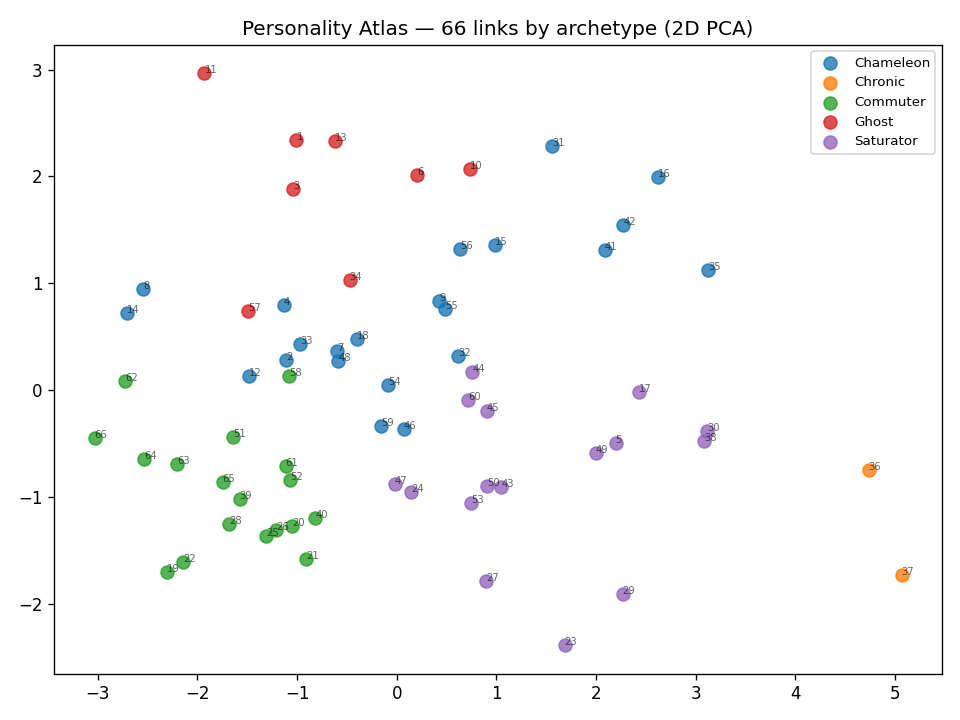

In [6]:
from IPython.display import Image
Image(str(config.ECHO_REPORTS_DIR/'personality_atlas.png'))